# Transfer Function Analysis - Example Circuit 1

Übertragungsfunktion zwischen Eingangsspannung `Uq` und Kondensatorspannung `U_C`.


In [1]:
from CircuitCalculator.Circuit.transfer_function import symbolic_transfer_function, numeric_transfer_function, TransferFunctionOutput
from CircuitCalculator.Circuit.circuit import Circuit
from CircuitCalculator.Circuit.Components import components as cmp
from scipy import signal
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


## Setup Circuit


In [ ]:
R1, R2, R3 = 10, 20, 30
C = 1e-3
V0 = 5

circuit = Circuit(
    components=[
        cmp.dc_voltage_source(id='Uq', V=V0, nodes=('1', '0')),
        cmp.resistor(id='R1', R=R1, nodes=('1', '2')),
        cmp.resistor(id='R2', R=R2, nodes=('2', '0')),
        cmp.resistor(id='R3', R=R3, nodes=('2', '3')),
        cmp.capacitor(id='C', C=C, nodes=('3', '0'))
    ],
    ground_node='0'
)


Circuit(components=[Component(type='dc_voltage_source', id='Uq', nodes=('1', '0'), value={'V': 5, 'R': 0, 'w': 0, 'phi': 0}), Component(type='resistor', id='R1', nodes=('1', '2'), value={'R': 10}), Component(type='resistor', id='R2', nodes=('2', '0'), value={'R': 20}), Component(type='resistor', id='R3', nodes=('2', '3'), value={'R': 30}), Component(type='capacitor', id='C', nodes=('3', '0'), value={'C': 0.001})], ground_node='0')

## Calculate Transfer Function


In [3]:
tf = symbolic_transfer_function(
    circuit,
    input_id='Uq',
    output=TransferFunctionOutput.voltage('C')
)
tf.expr


2/(3*(11*s/300 + 1))

In [4]:
s = tf.s
numerator = tf.numerator()
denominator = tf.denominator()
poles = tf.poles()
zeros = tf.zeros()

display(sp.Eq(sp.Symbol("H"), tf.expr))
print("Numerator:", numerator)
print("Denominator:", denominator)
print("Zeros:", zeros if zeros else "keine")
print("Poles:", poles)


Eq(H, 2/(3*(11*s/300 + 1)))

Numerator: 200
Denominator: 11*s + 300
Zeros: keine
Poles: [-300/11]


## Build Symbolic And Numeric Transfer Function


In [5]:
tf_symbolic = symbolic_transfer_function(
    circuit,
    input_id='Uq',
    output=TransferFunctionOutput.voltage('C')
)

tf_numeric = numeric_transfer_function(
    circuit,
    input_id='Uq',
    output=TransferFunctionOutput.voltage('C')
)

tf_symbolic.expr


TransferFunctionContinuous(
array([18.18181818]),
array([ 1.        , 27.27272727]),
dt: None
)

## Bode Diagram


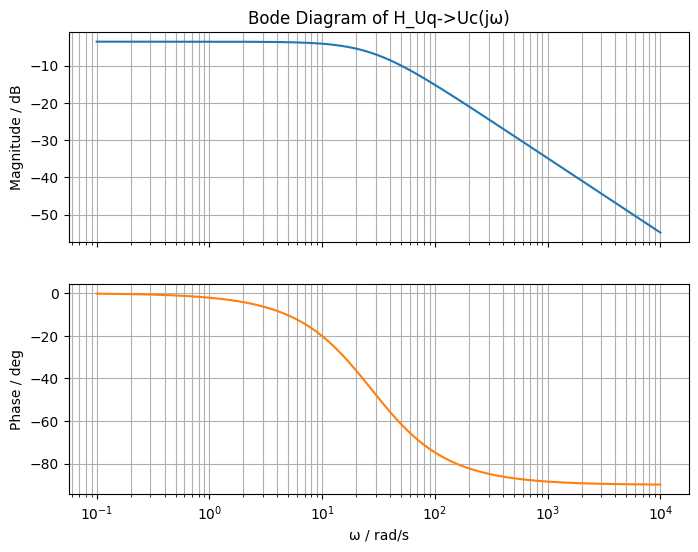

In [6]:
s = tf_symbolic.s
numerator = tf_symbolic.numerator()
denominator = tf_symbolic.denominator()
poles = tf_symbolic.poles()
zeros = tf_symbolic.zeros()

display(sp.Eq(sp.Symbol("H"), tf_symbolic.expr))
print("Numerator:", numerator)
print("Denominator:", denominator)
print("Zeros:", zeros if zeros else "keine")
print("Poles:", poles)
print("Numeric numerator coefficients:", tf_numeric.numerator_coeffs)
print("Numeric denominator coefficients:", tf_numeric.denominator_coeffs)


## Ortskurve


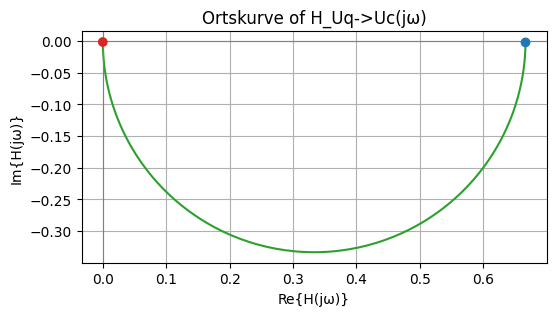

In [7]:
system = tf_numeric.transfer_function()
system


## Pole-Zero Diagram


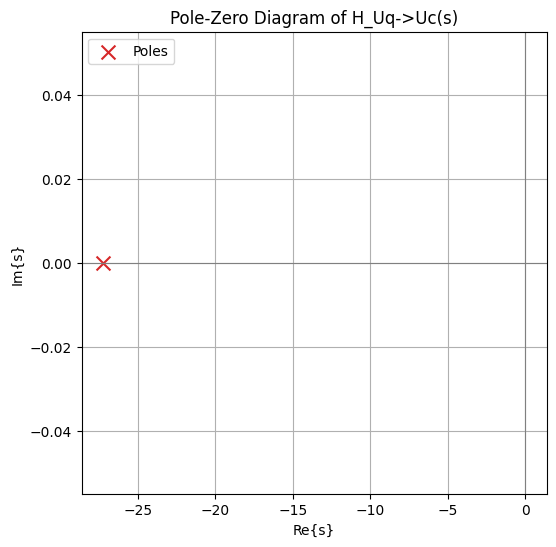

In [8]:
zero_values = np.array([complex(z.evalf()) for z in zeros], dtype=complex) if zeros else np.array([], dtype=complex)
pole_values = np.array([complex(p.evalf()) for p in poles], dtype=complex)

fig, ax = plt.subplots(figsize=(6, 6))
if zero_values.size > 0:
    ax.scatter(zero_values.real, zero_values.imag, marker="o", s=100, facecolors="none", edgecolors="tab:blue", label="Zeros")
ax.scatter(pole_values.real, pole_values.imag, marker="x", s=100, color="tab:red", label="Poles")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.axvline(0, color="0.5", linewidth=0.8)
ax.set_xlabel("Re{s}")
ax.set_ylabel("Im{s}")
ax.set_title("Pole-Zero Diagram of H_Uq->Uc(s)")
ax.grid(True)
ax.legend()
plt.show()
